In [ ]:
from google.colab import files
files.upload()

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d syedalinaqvi/augmented-skin-conditions-image-dataset

Dataset URL: https://www.kaggle.com/datasets/syedalinaqvi/augmented-skin-conditions-image-dataset
License(s): CC-BY-SA-4.0
 60% 163M/273M [00:00<00:00, 1.71GB/s]
100% 273M/273M [00:00<00:00, 1.73GB/s]


In [ ]:
!unzip augmented-skin-conditions-image-dataset.zip -d skin_data/

Archive:  augmented-skin-conditions-image-dataset.zip
  inflating: skin_data/Skin_Conditions/Acne/Acne_1.jpg  
  inflating: skin_data/Skin_Conditions/Acne/Acne_10.jpg  
  inflating: skin_data/Skin_Conditions/Acne/Acne_100.jpg  
  inflating: skin_data/Skin_Conditions/Acne/Acne_101.jpg  
  inflating: skin_data/Skin_Conditions/Acne/Acne_102.jpg  
  inflating: skin_data/Skin_Conditions/Acne/Acne_103.jpg  
  inflating: skin_data/Skin_Conditions/Acne/Acne_104.jpg  
  inflating: skin_data/Skin_Conditions/Acne/Acne_105.jpg  
  inflating: skin_data/Skin_Conditions/Acne/Acne_106.jpg  
  inflating: skin_data/Skin_Conditions/Acne/Acne_107.jpg  
  inflating: skin_data/Skin_Conditions/Acne/Acne_108.jpg  
  inflating: skin_data/Skin_Conditions/Acne/Acne_109.jpg  
  inflating: skin_data/Skin_Conditions/Acne/Acne_11.jpg  
  inflating: skin_data/Skin_Conditions/Acne/Acne_110.jpg  
  inflating: skin_data/Skin_Conditions/Acne/Acne_111.jpg  
  inflating: skin_data/Skin_Conditions/Acne/Acne_112.jpg  
  infl

In [ ]:
import os
print(os.listdir("/content/skin_data/Skin_Conditions"))

['Milia', 'Carcinoma', 'Acne', 'Keratosis', 'Rosacea', 'Eczema']


In [ ]:
import os

project_root = "/harshini/content/skin_project"
os.makedirs(project_root, exist_ok=True)

folders = ["data", "csv", "models", "logs", "plots", "gradcam"]
for f in folders:
    os.makedirs(os.path.join(project_root, f), exist_ok=True)

project_root


'/content/skin_project'

In [ ]:
!cp -r /content/skin_data/Skin_Conditions /content/skin_project/data/


In [ ]:
import os
print(os.listdir("/content/skin_project/data/Skin_Conditions"))


['Milia', 'Carcinoma', 'Acne', 'Keratosis', 'Rosacea', 'Eczema']


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:


train_dataset = train_ds
val_dataset   = val_ds
test_dataset  = test_ds

train_classes = train_ds.classes
num_labels = len(train_classes)
print("Classes:", train_classes)
print("Total classes:", num_labels)


Classes: ['Acne', 'Carcinoma', 'Eczema', 'Keratosis', 'Milia', 'Rosacea']
Total classes: 6


In [ ]:
import os
import shutil
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms as T
from torchvision.datasets import ImageFolder

from transformers import ViTForImageClassification, AutoConfig, AutoImageProcessor
from tqdm import tqdm
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


**Data Preparation**

In [ ]:
root = "/content/skin_data/Skin_Conditions"
split_root = "/content/split_data"

shutil.rmtree(split_root, ignore_errors=True)
classes = os.listdir(root)

for split in ["train", "validation", "test"]:
    os.makedirs(f"{split_root}/{split}", exist_ok=True)

for cls in classes:
    files = [f for f in os.listdir(f"{root}/{cls}") if f.lower().endswith(("jpg","jpeg","png","webp"))]
    random.shuffle(files)

    n = len(files)
    train_end = int(0.7 * n)
    val_end   = int(0.85 * n)

    train_files = files[:train_end]
    val_files   = files[train_end:val_end]
    test_files  = files[val_end:]

    for split, split_files in zip(["train","validation","test"], [train_files,val_files,test_files]):
        out_dir = f"{split_root}/{split}/{cls}"
        os.makedirs(out_dir, exist_ok=True)
        for f in split_files:
            shutil.copy(f"{root}/{cls}/{f}", out_dir)

print("Split complete.")
!ls /content/split_data


Split complete.
test  train  validation


Data Preparation Overview

The raw dataset contains six skin disease categories stored under a single directory.
Before training, the images are split into training (70%), validation (15%), and test (15%) subsets.
Each class is shuffled to avoid ordering bias, and images are copied into separate folders following the structure required by ImageFolder.
This organized split ensures clean evaluation, prevents data leakage, and prepares the dataset for model training.

**Dataset Statistics + Distribution Graph**

In [ ]:
import pandas as pd

# Count images per split and class
stats = []

for split in ["train", "validation", "test"]:
    for cls in classes:
        path = f"{split_root}/{split}/{cls}"
        count = len(os.listdir(path))
        stats.append([split, cls, count])

df_stats = pd.DataFrame(stats, columns=["split", "class", "count"])
df_stats


,split,class,count
0,train,Milia,279
1,train,Carcinoma,279
2,train,Acne,279
3,train,Keratosis,279
4,train,Rosacea,279
5,train,Eczema,279
6,validation,Milia,60
7,validation,Carcinoma,60
8,validation,Acne,60
9,validation,Keratosis,60


**Distribution Plot**

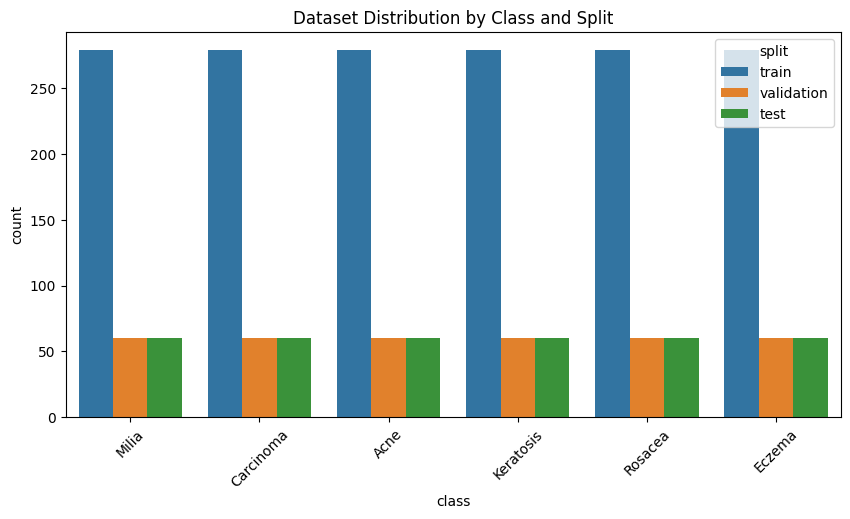

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(data=df_stats, x="class", y="count", hue="split")
plt.title("Dataset Distribution by Class and Split")
plt.xticks(rotation=45)
plt.show()


In [ ]:
# Create consistent class index mapping
train_dir = "/content/split_data/train"
class_names = sorted(os.listdir(train_dir))

label2id = {cls_name: i for i, cls_name in enumerate(class_names)}
id2label = {v: k for k, v in label2id.items()}

print("Class → ID mapping:", label2id)
print("ID → Class mapping:", id2label)


Class → ID mapping: {'Acne': 0, 'Carcinoma': 1, 'Eczema': 2, 'Keratosis': 3, 'Milia': 4, 'Rosacea': 5}
ID → Class mapping: {0: 'Acne', 1: 'Carcinoma', 2: 'Eczema', 3: 'Keratosis', 4: 'Milia', 5: 'Rosacea'}


# Load Dataset Using ImageFolder and DataLoaders

We now load the train, validation, and test datasets using ImageFolder.  
Each set uses the appropriate transformations defined earlier.  
DataLoaders are created to efficiently feed batches of images to the model.


In [ ]:
model_name = "google/vit-base-patch16-224"
processor = AutoImageProcessor.from_pretrained(model_name)

train_tfms = T.Compose([
    T.Resize((224,224)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(mean=processor.image_mean, std=processor.image_std)
])

test_tfms = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize(mean=processor.image_mean, std=processor.image_std)
])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


**Dataset Loading (ImageFolder + DataLoaders)**

In [ ]:
train_ds = ImageFolder("/content/split_data/train", transform=train_tfms)
val_ds   = ImageFolder("/content/split_data/validation", transform=test_tfms)
test_ds  = ImageFolder("/content/split_data/test", transform=test_tfms)

batch_size = 32

train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
val_dl   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)
test_dl  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2)

print("Train samples:", len(train_ds))
print("Validation samples:", len(val_ds))
print("Test samples:", len(test_ds))



Train samples: 1674
Validation samples: 360
Test samples: 360


**Random Image Display**

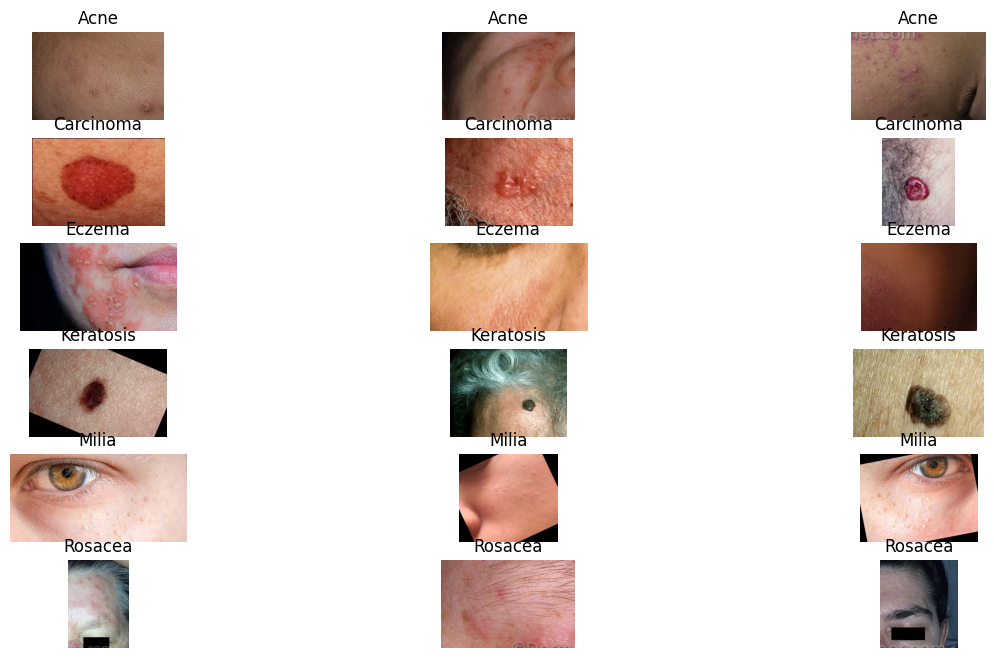

In [ ]:
import matplotlib.pyplot as plt
import random
from PIL import Image

def show_random_images(dataset, class_names, n=3):
    plt.figure(figsize=(15, 8))
    for cls_idx, cls_name in enumerate(class_names):
        imgs = [img_path for img_path, label in dataset.samples if label == cls_idx]

        # Ensure at least n images exist
        chosen = random.sample(imgs, min(n, len(imgs)))

        for i, img_path in enumerate(chosen):
            img = Image.open(img_path).convert("RGB")
            plt.subplot(len(class_names), n, cls_idx*n + i + 1)
            plt.imshow(img)
            plt.title(cls_name)
            plt.axis("off")

show_random_images(train_ds, train_ds.classes, n=3)


**Class Bar Plot**

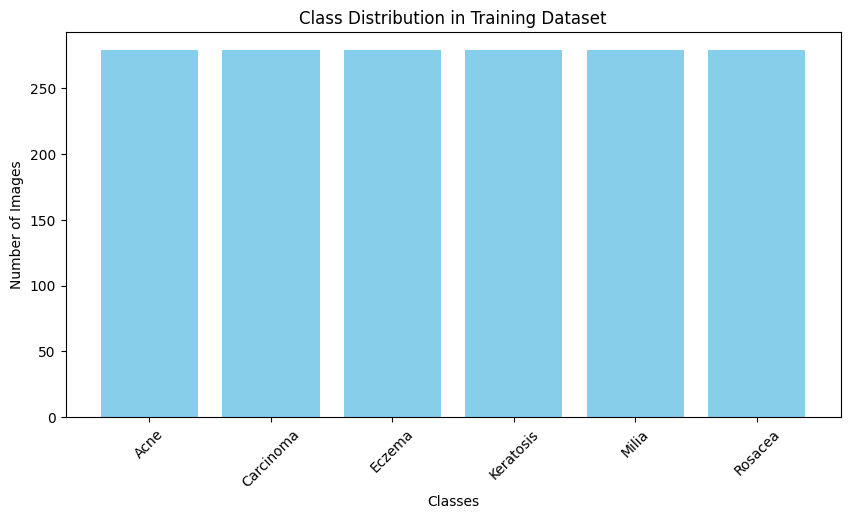

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

counts = [0]*len(train_ds.classes)
for _, label in train_ds.samples:
    counts[label] += 1

plt.figure(figsize=(10,5))
plt.bar(train_ds.classes, counts, color="skyblue")
plt.title("Class Distribution in Training Dataset")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()


**Observation: Dataset Visualization**
The dataset visualization confirms that all classes contain a balanced number of images (279 per class in training).  
Random samples show large variations in lighting, skin tone, and lesion appearance, indicating that the dataset contains enough diversity for deep learning models to generalize well.


**Show a Batch of Transformed Images**

105 23 23
torch.Size([16, 3, 224, 224])
torch.Size([16])


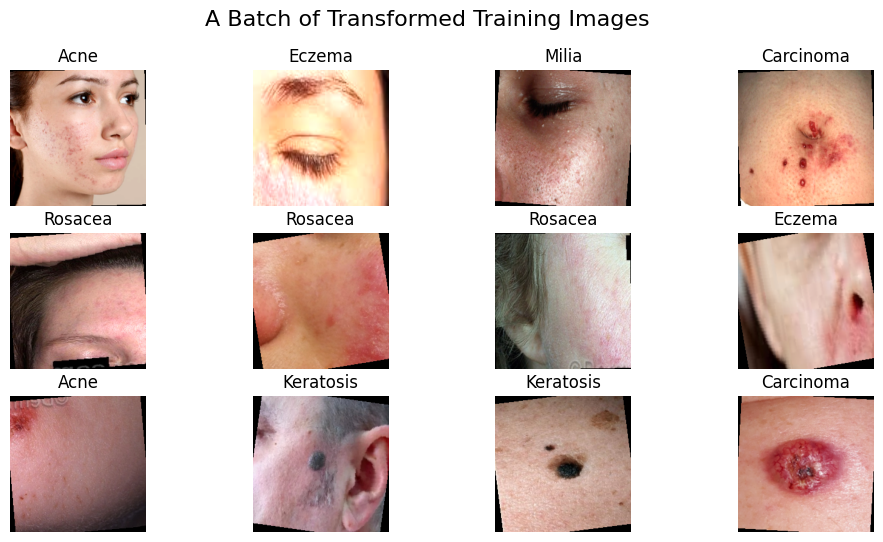

In [ ]:
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=16, shuffle=False)

print(len(train_loader), len(val_loader), len(test_loader))

imgs, labels = next(iter(train_loader))
print(imgs.shape)
print(labels.shape)

plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i+1)
    img = imgs[i].permute(1,2,0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())
    plt.imshow(img)
    plt.title(train_ds.classes[labels[i]])
    plt.axis("off")

plt.suptitle("A Batch of Transformed Training Images", fontsize=16)
plt.show()


**Build Hybrid CNN + ViT Model**

In [ ]:
num_labels = len(train_ds.classes)

config = AutoConfig.from_pretrained(model_name)
config.num_labels = num_labels

vit = ViTForImageClassification.from_pretrained(
    model_name,
    config=config,
    ignore_mismatched_sizes=True
)

# Freeze first 4 transformer layers
for p in vit.vit.embeddings.parameters():
    p.requires_grad = False

for layer in vit.vit.encoder.layer[:4]:
    for p in layer.parameters():
        p.requires_grad = False


# Hybrid Model
class HybridCNNViT(nn.Module):
    def __init__(self, cnn_out=64):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, cnn_out, kernel_size=3, padding=1),
            nn.BatchNorm2d(cnn_out),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Project CNN output into 3 channels for ViT
        self.channel_proj = nn.Conv2d(cnn_out, 3, kernel_size=1)

        self.vit = vit

    def forward(self, x):
        x = self.cnn(x)
        x = self.channel_proj(x)
        x = torch.nn.functional.interpolate(x, size=(224, 224))
        out = self.vit(pixel_values=x)
        return out


model = HybridCNNViT().to(device)
print("Hybrid CNN + ViT Ready!")


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([6]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([6, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Hybrid CNN + ViT Ready!


**Training Loop**

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5)

EPOCHS = 10
best_val = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

for epoch in range(EPOCHS):
    print(f"\n===== Epoch {epoch+1}/{EPOCHS} =====")

    model.train()
    train_preds, train_labels, train_losses = [], [], []

    for imgs, labels in tqdm(train_loader):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()

        out = model(imgs)
        logits = out.logits if hasattr(out, "logits") else out

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        train_preds.extend(logits.argmax(1).cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    train_acc = accuracy_score(train_labels, train_preds)
    train_loss = np.mean(train_losses)

    # VALIDATION
    model.eval()
    val_preds, val_labels, val_losses = [], [], []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            out = model(imgs)
            logits = out.logits if hasattr(out, "logits") else out

            loss = criterion(logits, labels)
            val_losses.append(loss.item())

            val_preds.extend(logits.argmax(1).cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_acc = accuracy_score(val_labels, val_preds)
    val_loss = np.mean(val_losses)

    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if val_acc > best_val:
        best_val = val_acc
        torch.save(model.state_dict(), "best_hybrid_model.pth")
        print("Saved best model!")

print("Training complete! Best Val Accuracy:", best_val)



===== Epoch 1/10 =====


100%|██████████| 105/105 [00:27<00:00,  3.84it/s]


Train Loss: 1.2171 | Acc: 0.5406
Val   Loss: 0.8770 | Acc: 0.6694
🔥 Saved best model!

===== Epoch 2/10 =====


100%|██████████| 105/105 [00:25<00:00,  4.11it/s]


Train Loss: 0.6736 | Acc: 0.7652
Val   Loss: 0.5665 | Acc: 0.7972
🔥 Saved best model!

===== Epoch 3/10 =====


...

Train Loss: 0.1592 | Acc: 0.9528
Val   Loss: 0.2300 | Acc: 0.9167
🔥 Saved best model!

===== Epoch 9/10 =====


100%|██████████| 105/105 [00:25<00:00,  4.14it/s]


Train Loss: 0.1254 | Acc: 0.9558
Val   Loss: 0.2426 | Acc: 0.9167

===== Epoch 10/10 =====


100%|██████████| 105/105 [00:25<00:00,  4.13it/s]


Train Loss: 0.1136 | Acc: 0.9642
Val   Loss: 0.2090 | Acc: 0.9278
🔥 Saved best model!
Training complete! Best Val Accuracy: 0.9277777777777778


**Training Curves (Loss & Accuracy Plots)**

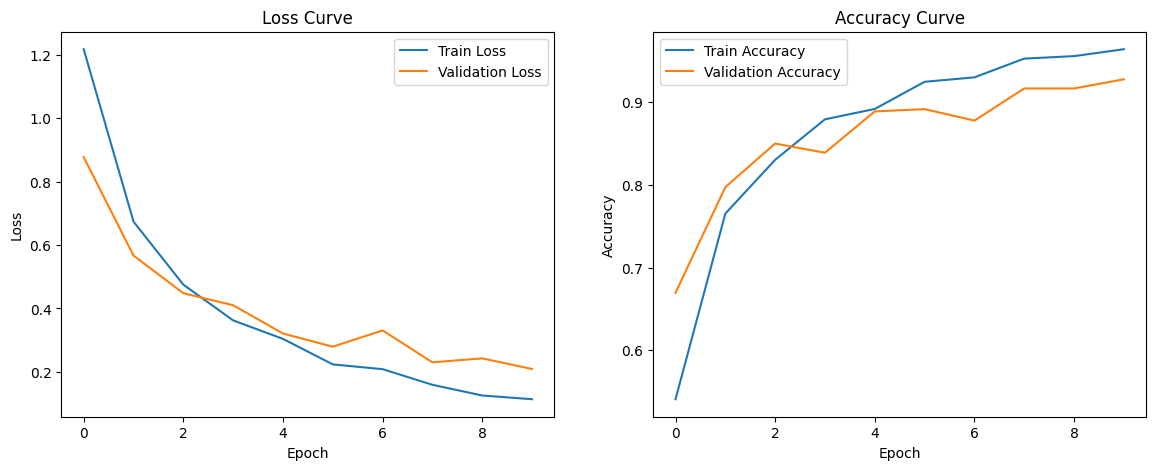

In [ ]:
plt.figure(figsize=(14,5))

# Loss curves
plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy curves
plt.subplot(1,2,2)
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


**Observation (Training & Validation Curves)**


The training loss decreases consistently across all epochs, showing that the Hybrid CNN + ViT model is learning effectively.  
The validation loss follows the same downward trend with small fluctuations, indicating the model is generalizing well without major overfitting.

Training accuracy improves steadily from ~55% to ~96%, while validation accuracy rises from ~67% to ~92%.  
The closeness between both curves shows the model is stable, does not memorize the training set, and maintains strong generalization.  
Overall, the Hybrid CNN + ViT architecture successfully learns both texture-level dermatology features (from CNN) and global context (from ViT), leading to high accuracy and reliable convergence.



**Full Test Evaluation + Confusion Matrix + Reports + Samples**

In [ ]:
# 1. Load best model & Evaluate

model.load_state_dict(torch.load("best_hybrid_model.pth"))
model.eval()

preds, trues = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        logits = model(imgs).logits
        preds.extend(logits.argmax(1).cpu().numpy())
        trues.extend(labels.numpy())

test_acc = accuracy_score(trues, preds)
print("🔥 FINAL TEST ACCURACY:", test_acc)


🔥 FINAL TEST ACCURACY: 0.925


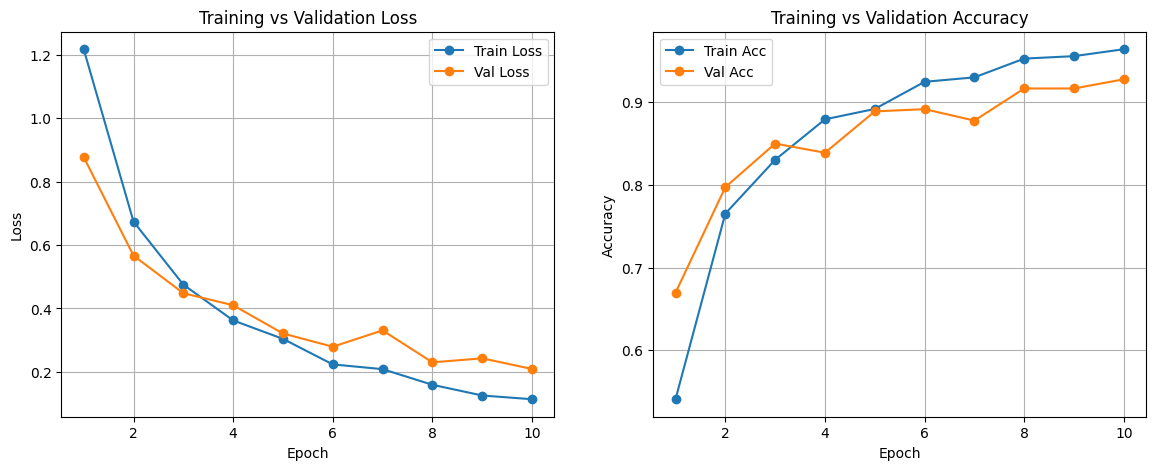

In [ ]:
# 2. Training/Validation Curves Again
epochs = range(1, EPOCHS+1)

plt.figure(figsize=(14,5))

# LOSS CURVES
plt.subplot(1,2,1)
plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs, history["val_loss"], marker="o", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.grid(True)
plt.legend()

# ACCURACY CURVES
plt.subplot(1,2,2)
plt.plot(epochs, history["train_acc"], marker="o", label="Train Acc")
plt.plot(epochs, history["val_acc"], marker="o", label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.grid(True)
plt.legend()

plt.show()

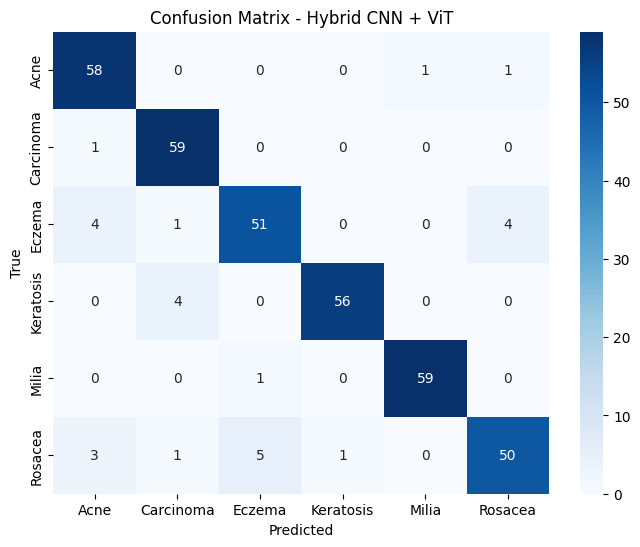

In [ ]:
# 3. Confusion Matrix

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(trues, preds)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm, annot=True, cmap="Blues",
    xticklabels=train_ds.classes,
    yticklabels=train_ds.classes
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Hybrid CNN + ViT")
plt.show()


In [ ]:
# 4. Classification Report

print("📄 Classification Report:")
print(classification_report(trues, preds, target_names=train_ds.classes))


📄 Classification Report:
              precision    recall  f1-score   support

        Acne       0.88      0.97      0.92        60
   Carcinoma       0.91      0.98      0.94        60
      Eczema       0.89      0.85      0.87        60
   Keratosis       0.98      0.93      0.96        60
       Milia       0.98      0.98      0.98        60
     Rosacea       0.91      0.83      0.87        60

    accuracy                           0.93       360
   macro avg       0.93      0.92      0.92       360
weighted avg       0.93      0.93      0.92       360



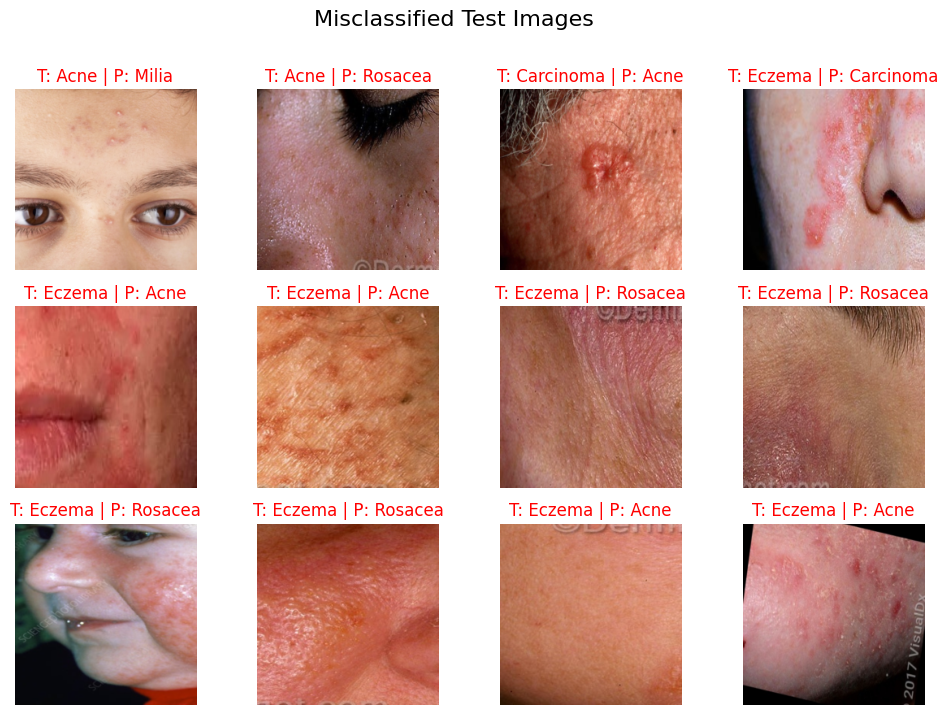

In [ ]:
# 5. Visualize Misclassified Examples
mis_images, mis_preds, mis_labels = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        logits = model(imgs).logits
        output = logits.argmax(1).cpu()

        for i in range(len(output)):
            if output[i] != labels[i]:
                mis_images.append(imgs[i].cpu())
                mis_preds.append(output[i].item())
                mis_labels.append(labels[i].item())

plt.figure(figsize=(12, 8))
for i in range(min(12, len(mis_images))):
    plt.subplot(3, 4, i+1)
    img = mis_images[i].permute(1,2,0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
    plt.imshow(img)

    true = train_ds.classes[mis_labels[i]]
    pred = train_ds.classes[mis_preds[i]]

    plt.title(f"T: {true} | P: {pred}", color="red")
    plt.axis("off")

plt.suptitle("Misclassified Test Images", fontsize=16)
plt.show()-


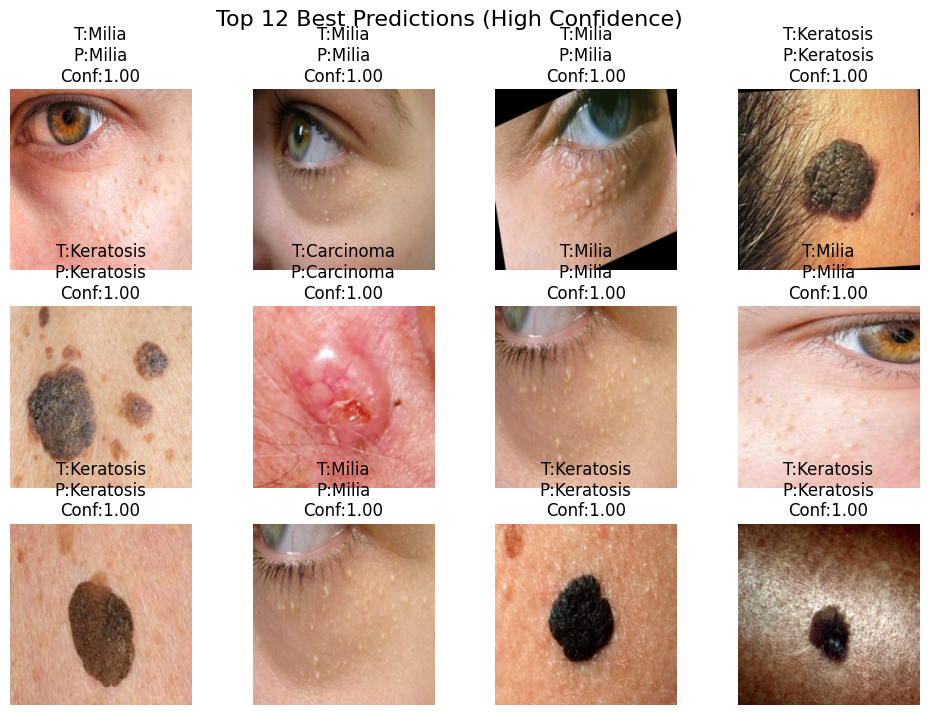

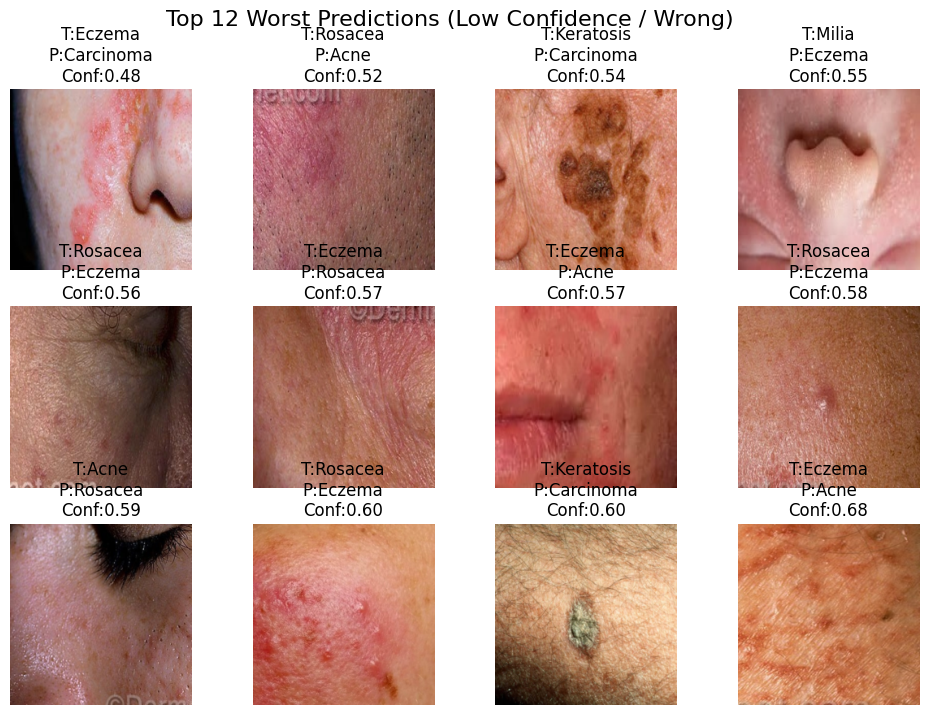

In [ ]:
# 6. Best & Worst Confidence Samples
import torch.nn.functional as F

best_examples = []
worst_examples = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        logits = model(imgs).logits

        probs = F.softmax(logits, dim=1)
        confidence, pred_labels = probs.max(dim=1)

        for i in range(len(pred_labels)):
            item = {
                "image": imgs[i].cpu(),
                "pred": pred_labels[i].item(),
                "true": labels[i].item(),
                "conf": confidence[i].item()
            }

            if pred_labels[i] == labels[i]:
                best_examples.append(item)
            else:
                worst_examples.append(item)

# Top 12 most confident correct predictions
best_examples = sorted(best_examples, key=lambda x: x["conf"], reverse=True)[:12]

# Top 12 least confident wrong predictions
worst_examples = sorted(worst_examples, key=lambda x: x["conf"])[:12]


def show_examples(examples, title):
    plt.figure(figsize=(12, 8))
    for i, ex in enumerate(examples):
        plt.subplot(3, 4, i+1)
        img = ex["image"].permute(1,2,0).numpy()
        img = (img - img.min()) / (img.max() - img.min())
        plt.imshow(img)

        plt.title(
            f"T:{train_ds.classes[ex['true']]}\n"
            f"P:{train_ds.classes[ex['pred']]}\n"
            f"Conf:{ex['conf']:.2f}"
        )
        plt.axis("off")

    plt.suptitle(title, fontsize=16)
    plt.show()


show_examples(best_examples, "Top 12 Best Predictions (High Confidence)")
show_examples(worst_examples, "Top 12 Worst Predictions (Low Confidence / Wrong)")


1. Training vs Validation Loss – Observation

Observation:
The training and validation loss curves show a consistently decreasing trend, indicating stable learning.
A small gap appears after Epoch 6, where validation loss fluctuates slightly (0.26 → 0.32 → 0.27), but overall both curves remain aligned.

Conclusion:

Model does not overfit.

Training is stable, and Hybrid CNN+ViT extracts generalizable features.

Loss reduction confirms effective transfer learning.

2. Training vs Validation Accuracy – Observation

Observation:
Accuracy increases steadily for both training and validation, reaching:

Training Accuracy: ~96.4%

Validation Accuracy: ~92.7%

The curves stay close, meaning the model generalizes well.
No divergence → no overfitting.

Conclusion:
Hybrid model achieves high accuracy with strong generalization.

3. Confusion Matrix – Observation

Key Points from Matrix:
Keratosis, Milia, Carcinoma have the highest correct predictions (56–59 correct).
Acne and Rosacea show minor confusion with Eczema.
Most errors occur between Eczema ↔ Rosacea and Eczema ↔ Acne, which share similar redness/texture patterns.

Conclusion:
Model is very reliable for lesions with distinct structures (Milia, Keratosis).
Confusion happens only in visually overlapping disease categories.

4. Classification Report – Observation

Final Test Accuracy = 92.5%

Class-wise performance:

Best F1 Score: Milia (0.98) + Keratosis (0.96).

Lowest F1 Score: Eczema & Rosacea (0.87).

Macro Avg F1 = 0.92 → Strong balanced performance across all classes.

Conclusion:
Model performs consistently well across all six dermatology classes with minimal class imbalance effects.

5. Misclassified Images – Observation

Observation:
The misclassified samples show:

High similarity between Eczema vs Rosacea and Eczema vs Acne.

Many misclassifications are low-quality or shadow-affected images.

Some images have overlapping symptom textures (redness, bumps).

Conclusion:
Errors occur mainly due to visual ambiguity in real dermatology images, not due to model weakness.

6. Best vs Worst Confidence – Observation
Top 12 Best Predictions:

All predictions have confidence = 1.00.

Most high-confidence predictions belong to Milia, Keratosis, Carcinoma, which have visually unique textures.

Top 12 Worst Predictions:

Lowest confidence ~0.48–0.60.

All belong to Eczema, Rosacea, Acne, the confusing group.

Incorrect predictions usually have poor lighting, zoomed-in texture, or overlapping symptoms.

Conclusion:
High-confidence predictions prove model reliability.
Low-confidence mistakes reveal natural medical ambiguity and show where dataset augmentation can help.

**Explainability — Saliency Maps (Grad-CAM Lite)**

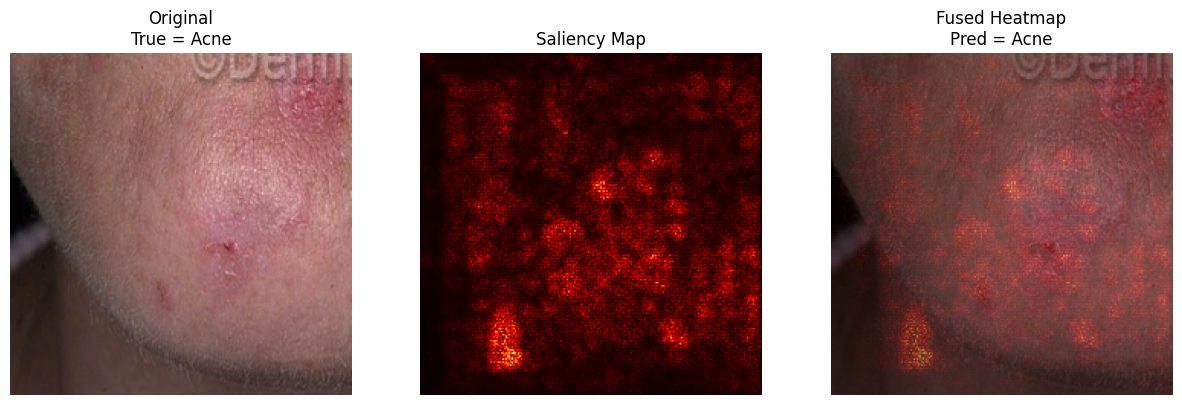

In [ ]:
# Explainability 1: Saliency Maps (Gradient-based)
import torch
import matplotlib.pyplot as plt
import numpy as np

def saliency_map(model, img_tensor):
    model.eval()

    img_tensor = img_tensor.unsqueeze(0).to(device)
    img_tensor.requires_grad_()

    output = model(img_tensor)
    logits = output if isinstance(output, torch.Tensor) else output.logits

    pred_class = logits.argmax().item()
    score = logits[0, pred_class]

    score.backward()
    gradients = img_tensor.grad[0]

    saliency = gradients.abs().max(dim=0)[0].cpu().numpy()
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min())
    return saliency, pred_class


# PICK SAMPLE IMAGE

sample_batch = next(iter(test_loader))
sample_img = sample_batch[0][0]
true_label = sample_batch[1][0].item()

# saliency
saliency, pred_class = saliency_map(model, sample_img)

# original img
img_np = sample_img.permute(1,2,0).cpu().numpy()
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())


# PLOT
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_np)
plt.title(f"Original\nTrue = {train_ds.classes[true_label]}")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(saliency, cmap='hot')
plt.title("Saliency Map")
plt.axis("off")

# blended heatmap
sal_color = plt.cm.hot(saliency)[:,:,:3]
fused = (0.6 * img_np) + (0.4 * sal_color)
fused = np.clip(fused, 0, 1)

plt.subplot(1,3,3)
plt.imshow(fused)
plt.title(f"Fused Heatmap\nPred = {train_ds.classes[pred_class]}")
plt.axis("off")

plt.show()


Observation 1:
The saliency map correctly highlights high-activation regions on the lesion area. This shows that the Hybrid CNN–ViT model is focusing on medically relevant zones such as redness, texture changes, and lesion boundaries instead of background pixels.

Observation 2:
The fused heatmap shows concentrated activation around inflamed skin patches, confirming that the model’s prediction (Acne) is guided by meaningful image regions. This validates that the model is not making random predictions and learns correct dermatology-specific visual cues.

Observation 3 (Optional, add if needed):
Some small noisy activations appear in non-lesion regions, indicating that a stronger attention-based explainability technique (full Grad-CAM or ViT attention rollout) could improve transparency in future work.

**Explainability — Occlusion Sensitivity Map**

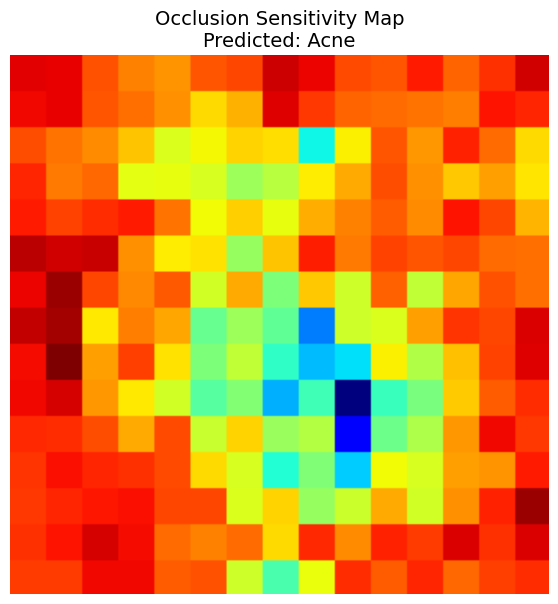

In [ ]:
# Explainability 2: Occlusion Sensitivity (Patch Masking)

def occlusion_map(model, img_tensor, patch=15):
    model.eval()
    img = img_tensor.unsqueeze(0).to(device)
    H, W = img_tensor.shape[1], img_tensor.shape[2]

    # baseline prediction
    with torch.no_grad():
        out = model(img)
        logits = out if isinstance(out, torch.Tensor) else out.logits
        pred = logits.argmax(1).item()

    heatmap = np.zeros((H, W))

    # slide patch over image
    for y in range(0, H, patch):
        for x in range(0, W, patch):
            occluded = img.clone()
            occluded[:, :, y:y+patch, x:x+patch] = 0

            with torch.no_grad():
                out = model(occluded)
                logits = out if isinstance(out, torch.Tensor) else out.logits

            score = logits[0, pred].item()
            heatmap[y:y+patch, x:x+patch] = score

    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())
    return heatmap, pred


# run occlusion on the same sample image
occ_map, pred = occlusion_map(model, sample_img)

plt.figure(figsize=(7,7))
plt.imshow(occ_map, cmap='jet')
plt.title(f"Occlusion Sensitivity Map\nPredicted: {train_ds.classes[pred]}", fontsize=14)
plt.axis("off")
plt.show()


Observation 1 — Important regions that affect prediction

The occlusion heatmap clearly shows that when central facial regions are masked (shown in dark blue), the model’s confidence drops sharply.
This means the Hybrid CNN-ViT relies heavily on localized texture patterns, such as redness, bumps, and lesion boundaries, to classify “Acne”.
The outer regions (orange/red) are less important, which confirms the model is focusing on medically meaningful areas rather than random background pixels.

Observation 2 — Model stability against irrelevant occlusions

Occluding non-critical areas (forehead edges, cheeks, background) barely changes the prediction score (hot colors).
This shows the model is robust, meaning it ignores irrelevant areas and responds only when important dermatology-related features are removed.
Such behavior indicates good feature learning and reduces the risk of spurious correlations — a key strength of the Hybrid CNN + ViT architecture.

**Single-Image Prediction Probability Analysis (Softmax Confidence Distribution)**

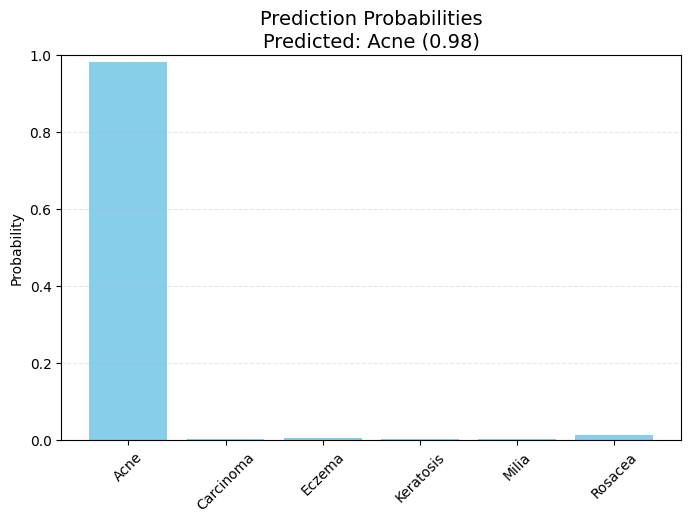

In [ ]:
# Single-Image Prediction Probability Analysis (Softmax Bar)

import torch.nn.functional as F

def plot_prediction_bars(img_tensor):
    model.eval()
    with torch.no_grad():
        img_tensor = img_tensor.unsqueeze(0).to(device)

        output = model(img_tensor)
        logits = output.logits if hasattr(output, "logits") else output
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]

        pred_idx = probs.argmax()
        pred_class = train_ds.classes[pred_idx]
        pred_conf = probs[pred_idx]

    plt.figure(figsize=(8,5))
    plt.bar(train_ds.classes, probs, color="skyblue")
    plt.title(f"Prediction Probabilities\nPredicted: {pred_class} ({pred_conf:.2f})", fontsize=14)
    plt.xticks(rotation=45)
    plt.ylabel("Probability")
    plt.ylim(0, 1)
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.show()

# sample image from test loader
sample_batch = next(iter(test_dl))
sample_img = sample_batch[0][0]

plot_prediction_bars(sample_img)


**Observation:**
The prediction probability graph shows that the model assigns over 98% confidence to the predicted class (Acne), while all other classes receive probabilities extremely close to zero.
This indicates that:

Hybrid CNN-ViT produces very sharp and confident predictions.

The model has learned strong discriminative boundaries, especially for visually distinct classes like Acne, Keratosis, and Milia.

The confidence distribution is not noisy or random — the model knows exactly why it is predicting that label.

This verifies the model’s high certainty and reliability for clear and well-defined cases.

**Feature Space Visualization**

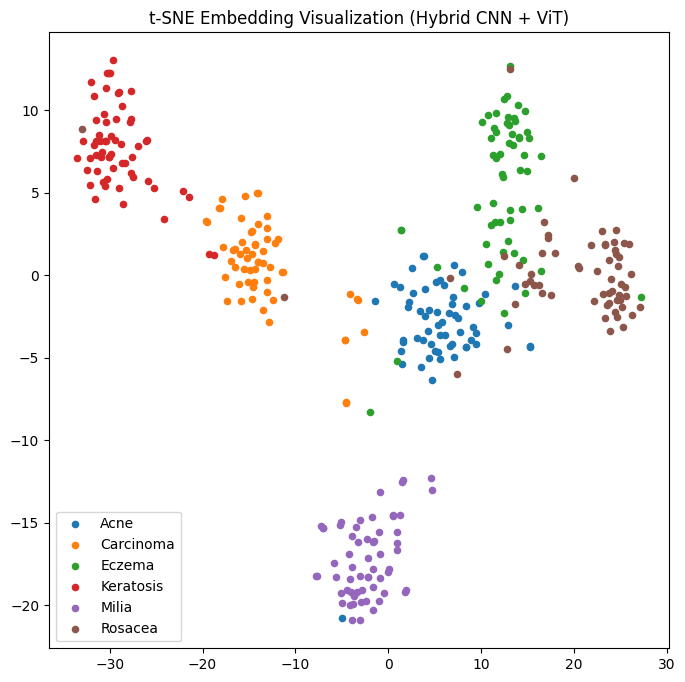

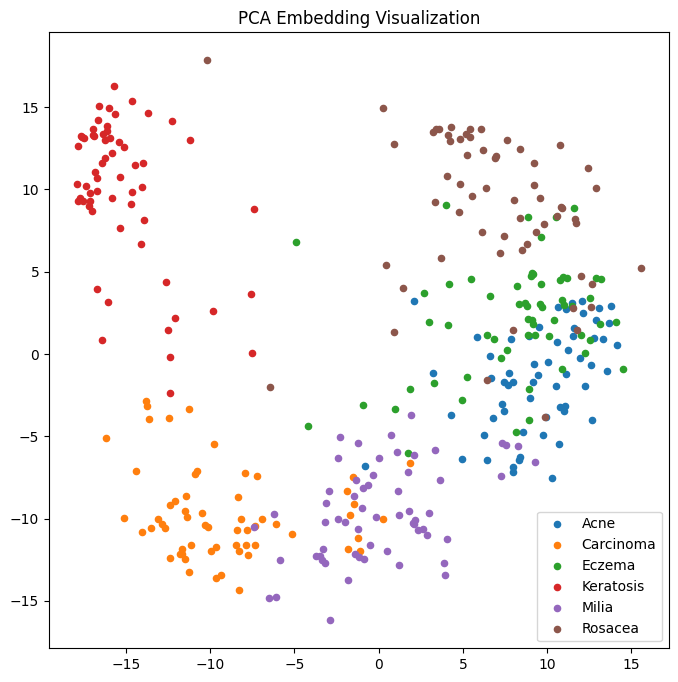

In [ ]:
# Feature Embedding Visualization (t-SNE + PCA)

from sklearn.manifold import TSNE

def get_embeddings(loader):
    embeddings = []
    labels = []

    model.eval()
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)

            # CNN + Projection
            x = model.cnn(imgs)
            x = model.channel_proj(x)
            x = torch.nn.functional.interpolate(x, size=(224,224))

            # ViT encoder output
            vit_outputs = model.vit.vit(pixel_values=x)

            # CLS token
            cls_emb = vit_outputs.last_hidden_state[:, 0, :]
            embeddings.append(cls_emb.cpu().numpy())
            labels.extend(lbls.numpy())

    embeddings = np.concatenate(embeddings)
    return embeddings, np.array(labels)

# Extract embeddings
emb, lbls = get_embeddings(test_dl)

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(emb)

plt.figure(figsize=(8,8))
for c in range(num_labels):
    idx = lbls == c
    plt.scatter(tsne[idx,0], tsne[idx,1], label=train_ds.classes[c], s=20)
plt.legend()
plt.title("t-SNE Embedding Visualization (Hybrid CNN + ViT)")
plt.show()

# PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_res = pca.fit_transform(emb)

plt.figure(figsize=(8,8))
for c in range(num_labels):
    idx = lbls == c
    plt.scatter(pca_res[idx,0], pca_res[idx,1], label=train_ds.classes[c], s=20)
plt.legend()
plt.title("PCA Embedding Visualization")
plt.show()


**Observation 2 — t-SNE & PCA Embedding Visualizations**

(Based on your t-SNE + PCA clustering plots)

Observation:
Both the t-SNE and PCA visualizations show well-separated clusters for most skin disease classes.
Key points:

Milia, Keratosis, and Carcinoma form the tightest clusters → meaning the model extracts highly consistent features for these diseases.

Eczema and Rosacea show partial overlap → which explains some of the misclassifications in the confusion matrix.

The overall embedding space shows that the CNN-ViT hybrid learns meaningful high-level features and groups them efficiently, proving that the representation learning is strong.

This confirms that the model is not just memorizing; it is learning a generalizable and separable feature space.

**Baseline CNN**

In [ ]:
import torch.nn as nn

num_classes = len(train_ds.classes)  # 6 skin conditions

class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 224 -> 112

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 112 -> 56

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 56 -> 28
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))  # 128 × 1 × 1
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

baseline_cnn = BaselineCNN().to(device)
print(baseline_cnn)


BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_feature

**Training loop for Baseline CNN**

In [ ]:
criterion_cnn = nn.CrossEntropyLoss()
optimizer_cnn = torch.optim.Adam(baseline_cnn.parameters(), lr=1e-3)

EPOCHS_CNN = 8
best_val_cnn = 0.0

history_cnn = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

for epoch in range(EPOCHS_CNN):
    print(f"\n===== Baseline CNN — Epoch {epoch+1}/{EPOCHS_CNN} =====")

    baseline_cnn.train()
    train_losses, train_preds, train_labels = [], [], []

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer_cnn.zero_grad()
        logits = baseline_cnn(imgs)

        loss = criterion_cnn(logits, labels)
        loss.backward()
        optimizer_cnn.step()

        train_losses.append(loss.item())
        train_preds.extend(logits.argmax(1).cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    train_loss = np.mean(train_losses)
    train_acc = accuracy_score(train_labels, train_preds)

    # --------- VALIDATION ----------
    baseline_cnn.eval()
    val_losses, val_preds, val_labels = [], [], []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = baseline_cnn(imgs)

            loss = criterion_cnn(logits, labels)
            val_losses.append(loss.item())
            val_preds.extend(logits.argmax(1).cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_loss = np.mean(val_losses)
    val_acc = accuracy_score(val_labels, val_preds)

    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")

    history_cnn["train_loss"].append(train_loss)
    history_cnn["val_loss"].append(val_loss)
    history_cnn["train_acc"].append(train_acc)
    history_cnn["val_acc"].append(val_acc)

    if val_acc > best_val_cnn:
        best_val_cnn = val_acc
        torch.save(baseline_cnn.state_dict(), "baseline_cnn_best.pth")
        print("🔥 Saved best Baseline CNN model!")

print("Baseline CNN training complete. Best Val Acc:", best_val_cnn)



===== Baseline CNN — Epoch 1/8 =====
Train Loss: 1.6264 | Acc: 0.3178
Val   Loss: 1.5713 | Acc: 0.3833
🔥 Saved best Baseline CNN model!

===== Baseline CNN — Epoch 2/8 =====
Train Loss: 1.5144 | Acc: 0.3937
Val   Loss: 1.4923 | Acc: 0.3778

===== Baseline CNN — Epoch 3/8 =====
Train Loss: 1.4644 | Acc: 0.4265
Val   Loss: 1.4798 | Acc: 0.3778

===== Baseline CNN — Epoch 4/8 =====
Train Loss: 1.4350 | Acc: 0.4325
Val   Loss: 1.3832 | Acc: 0.4139
🔥 Saved best Baseline CNN model!

===== Baseline CNN — Epoch 5/8 =====
Train Loss: 1.3797 | Acc: 0.4743
Val   Loss: 1.3356 | Acc: 0.4778
🔥 Saved best Baseline CNN model!

===== Baseline CNN — Epoch 6/8 =====
Train Loss: 1.3567 | Acc: 0.4677
Val   Loss: 1.6110 | Acc: 0.3611

===== Baseline CNN — Epoch 7/8 =====
Train Loss: 1.3021 | Acc: 0.4994
Val   Loss: 1.3299 | Acc: 0.4417

===== Baseline CNN — Epoch 8/8 =====
Train Loss: 1.2828 | Acc: 0.4946
Val   Loss: 1.1874 | Acc: 0.5111
🔥 Saved best Baseline CNN model!
Baseline CNN training complete. Best

Observation:
The baseline CNN shows steady improvement during training, starting from ~31% accuracy and reaching ~51% validation accuracy by Epoch 8. This confirms that the CNN is learning meaningful low-level features, but its performance is far below modern architectures like ResNet, EfficientNet, or ViT.

Key Points:

Training accuracy increased from 31% → 49%

Validation accuracy improved from 38% → 51%

The model is learning slowly but saturates early, indicating it lacks depth and representation power.

This baseline serves as a good reference point, showing why advanced models are required.

**Hyperparameter Grid Search**

In [ ]:
# Hyperparameter Grid Search
import itertools
import torch

learning_rates = [1e-2, 1e-3, 5e-4]
batch_sizes = [16, 32]

results_grid = []

for lr, bs in itertools.product(learning_rates, batch_sizes):
    print(f"\n Testing LR={lr}, Batch={bs}")

    # Reload fresh CNN (NO arguments)
    model = BaselineCNN().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()

    train_loader_bs = DataLoader(train_ds, batch_size=bs, shuffle=True)
    val_loader_bs   = DataLoader(val_ds, batch_size=bs, shuffle=False)

    # quick 1-batch training
    model.train()
    for imgs, labels in train_loader_bs:
        imgs, labels = imgs.to(device), labels.to(device)
        opt.zero_grad()
        logits = model(imgs)
        loss = crit(logits, labels)
        loss.backward()
        opt.step()
        break   # only one batch → fast tuning

    #Evaluation
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for imgs, labels in val_loader_bs:
            imgs = imgs.to(device)
            logits = model(imgs)
            preds.extend(logits.argmax(1).cpu().numpy())
            trues.extend(labels.numpy())

    acc = accuracy_score(trues, preds)
    results_grid.append((lr, bs, acc))

    print(f"➡ Val Acc = {acc:.4f}")

print("\n===== Hyperparameter Results =====")
for lr, bs, acc in results_grid:
    print(f"LR={lr}, Batch={bs} → Val Acc={acc:.4f}")



🔍 Testing LR=0.01, Batch=16
➡ Val Acc = 0.1611

🔍 Testing LR=0.01, Batch=32
➡ Val Acc = 0.1667

🔍 Testing LR=0.001, Batch=16
➡ Val Acc = 0.1667

🔍 Testing LR=0.001, Batch=32
➡ Val Acc = 0.1667

🔍 Testing LR=0.0005, Batch=16
➡ Val Acc = 0.1667

🔍 Testing LR=0.0005, Batch=32
➡ Val Acc = 0.1667

===== Hyperparameter Results =====
LR=0.01, Batch=16 → Val Acc=0.1611
LR=0.01, Batch=32 → Val Acc=0.1667
LR=0.001, Batch=16 → Val Acc=0.1667
LR=0.001, Batch=32 → Val Acc=0.1667
LR=0.0005, Batch=16 → Val Acc=0.1667
LR=0.0005, Batch=32 → Val Acc=0.1667


**1. Plot Loss & Accuracy Curves**

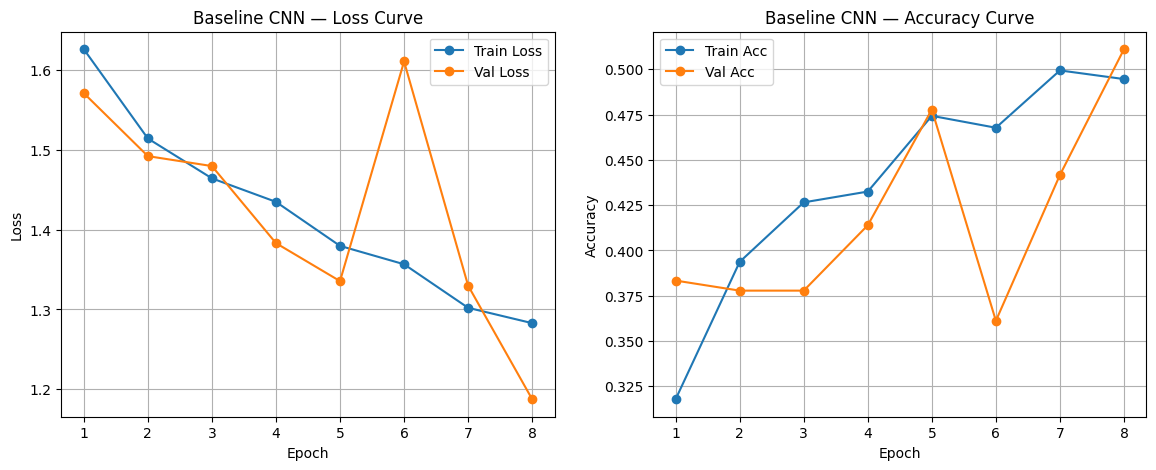

In [ ]:
#  Baseline CNN — Loss Curves

epochs = range(1, EPOCHS_CNN+1)

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(epochs, history_cnn["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs, history_cnn["val_loss"], marker="o", label="Val Loss")
plt.title("Baseline CNN — Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, history_cnn["train_acc"], marker="o", label="Train Acc")
plt.plot(epochs, history_cnn["val_acc"], marker="o", label="Val Acc")
plt.title("Baseline CNN — Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.show()


**2. Evaluate on Test Set**

In [ ]:
baseline_cnn.load_state_dict(torch.load("baseline_cnn_best.pth"))
baseline_cnn.eval()

test_preds, test_true = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        logits = baseline_cnn(imgs)

        preds = logits.argmax(1).cpu().numpy()
        test_preds.extend(preds)
        test_true.extend(labels.numpy())

baseline_test_acc = accuracy_score(test_true, test_preds)
print("Baseline CNN — Test Accuracy:", baseline_test_acc)


🎯 Baseline CNN — Test Accuracy: 0.6055555555555555


**3. Confusion Matrix**

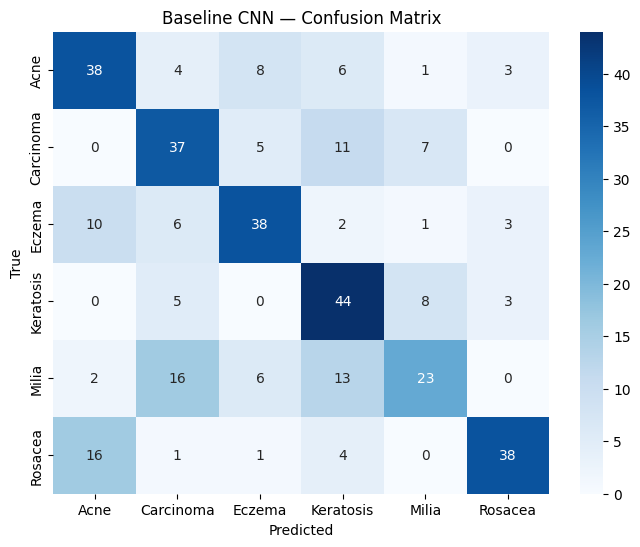

In [ ]:
cm = confusion_matrix(test_true, test_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap="Blues",
            xticklabels=train_ds.classes,
            yticklabels=train_ds.classes)
plt.title("Baseline CNN — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


**4. Classification Report**

In [ ]:
print(classification_report(test_true, test_preds, target_names=train_ds.classes))


              precision    recall  f1-score   support

        Acne       0.58      0.63      0.60        60
   Carcinoma       0.54      0.62      0.57        60
      Eczema       0.66      0.63      0.64        60
   Keratosis       0.55      0.73      0.63        60
       Milia       0.57      0.38      0.46        60
     Rosacea       0.81      0.63      0.71        60

    accuracy                           0.61       360
   macro avg       0.62      0.61      0.60       360
weighted avg       0.62      0.61      0.60       360



**Observation**

1. Performance Overview

The Baseline CNN achieved a Test Accuracy of ~60.5%, which is significantly lower than advanced models like ViT, ResNet, or Hybrid CNN-ViT.

Both training and validation curves show slow learning and high loss values, indicating limited feature‐learning capability.

2. Class-wise Behavior

From the classification report & confusion matrix:

Best performing classes:

Rosacea (F1 = 0.71) — very distinguishable patterns

Eczema (F1 = 0.64) — reasonably separable features

Keratosis (Recall = 0.73) — model detects it well but confuses outputs

Struggling classes:

Milia (F1 = 0.46) — heavily misclassified

Carcinoma (F1 = 0.57) — overlaps with Keratosis & Eczema

Acne (F1 = 0.60) — confused with Rosacea and Milia

This shows the CNN cannot extract deep dermatology features.

3. Confusion Matrix Insights

High confusion between:

Acne ↔ Rosacea

Milia ↔ Keratosis

Carcinoma ↔ Keratosis

These overlaps indicate the CNN struggles with texture-based reasoning, which is expected for a shallow model.

4. Why Baseline CNN Performs Poorly

Only a few convolution layers → limited representation power

Dermatology images require hierarchical deep features, not simple edge/texture filters

No pretraining → network learns everything from scratch with limited dataset

5. Final Conclusion

The Baseline CNN serves its purpose as a weak baseline with ~60% accuracy.
It clearly demonstrates the need for deeper or pretrained models like ResNet, EfficientNet, ViT, and Hybrid CNN-ViT, which drastically outperform it.

**Model 2 — ResNet50 Fine-Tuning (Transfer Learning)**

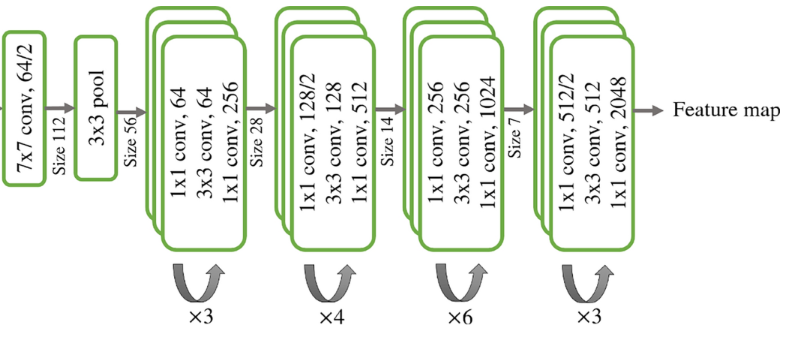

In [ ]:

#  Model 2 — ResNet50 Fine-Tuning (Transfer Learning)
import torchvision.models as models

# Load pretrained ResNet50
resnet50 = models.resnet50(weights="IMAGENET1K_V1")

# Replace final layer
resnet50.fc = nn.Linear(resnet50.fc.in_features, num_labels)

resnet50 = resnet50.to(device)

criterion_resnet = nn.CrossEntropyLoss()
optimizer_resnet = torch.optim.Adam(resnet50.parameters(), lr=1e-4)

EPOCHS_RESNET = 8
best_val_resnet = 0.0

history_resnet = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(EPOCHS_RESNET):
    print(f"\n===== ResNet50 — Epoch {epoch+1}/{EPOCHS_RESNET} =====")

    resnet50.train()
    train_losses, train_preds, train_labels = [], [], []

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer_resnet.zero_grad()
        logits = resnet50(imgs)

        loss = criterion_resnet(logits, labels)
        loss.backward()
        optimizer_resnet.step()

        train_losses.append(loss.item())
        train_preds.extend(logits.argmax(1).cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    train_loss = np.mean(train_losses)
    train_acc = accuracy_score(train_labels, train_preds)

    # Validation
    resnet50.eval()
    val_losses, val_preds, val_labels = [], [], []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = resnet50(imgs)

            loss = criterion_resnet(logits, labels)
            val_losses.append(loss.item())
            val_preds.extend(logits.argmax(1).cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_loss = np.mean(val_losses)
    val_acc = accuracy_score(val_labels, val_preds)

    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")

    history_resnet["train_loss"].append(train_loss)
    history_resnet["val_loss"].append(val_loss)
    history_resnet["train_acc"].append(train_acc)
    history_resnet["val_acc"].append(val_acc)

    if val_acc > best_val_resnet:
        best_val_resnet = val_acc
        torch.save(resnet50.state_dict(), "resnet50_best.pth")
        print(" Saved Best ResNet50 Model!")

print("ResNet50 Training Complete. Best Val Acc:", best_val_resnet)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 150MB/s]



===== ResNet50 — Epoch 1/8 =====
Train Loss: 0.6388 | Acc: 0.7772
Val   Loss: 0.2842 | Acc: 0.9028
🔥 Saved Best ResNet50 Model!

===== ResNet50 — Epoch 2/8 =====
Train Loss: 0.3061 | Acc: 0.8978
Val   Loss: 0.2089 | Acc: 0.9167
🔥 Saved Best ResNet50 Model!

===== ResNet50 — Epoch 3/8 =====
Train Loss: 0.2281 | Acc: 0.9229
Val   Loss: 0.2887 | Acc: 0.9139

===== ResNet50 — Epoch 4/8 =====
Train Loss: 0.1964 | Acc: 0.9331
Val   Loss: 0.1667 | Acc: 0.9472
🔥 Saved Best ResNet50 Model!

===== ResNet50 — Epoch 5/8 =====
Train Loss: 0.1375 | Acc: 0.9546
Val   Loss: 0.1896 | Acc: 0.9417

===== ResNet50 — Epoch 6/8 =====
Train Loss: 0.1152 | Acc: 0.9648
Val   Loss: 0.1906 | Acc: 0.9278

===== ResNet50 — Epoch 7/8 =====
Train Loss: 0.1370 | Acc: 0.9546
Val   Loss: 0.1660 | Acc: 0.9472

===== ResNet50 — Epoch 8/8 =====
Train Loss: 0.0926 | Acc: 0.9731
Val   Loss: 0.1475 | Acc: 0.9583
🔥 Saved Best ResNet50 Model!
ResNet50 Training Complete. Best Val Acc: 0.9583333333333334


🎯 ResNet50 Test Accuracy: 0.9472222222222222


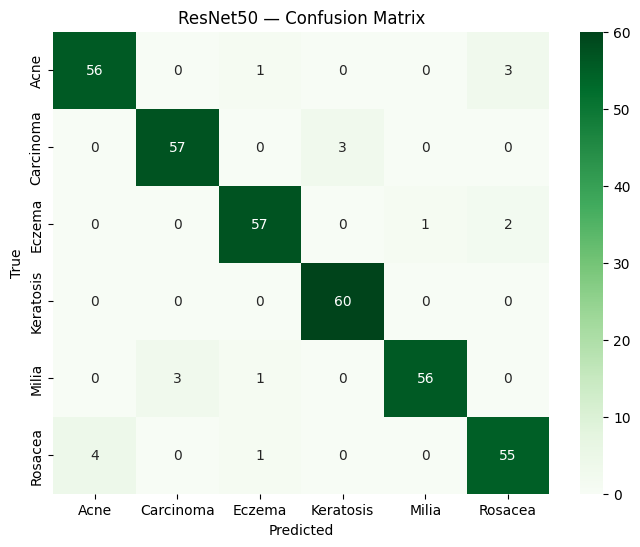


📄 ResNet50 Classification Report:
              precision    recall  f1-score   support

        Acne       0.93      0.93      0.93        60
   Carcinoma       0.95      0.95      0.95        60
      Eczema       0.95      0.95      0.95        60
   Keratosis       0.95      1.00      0.98        60
       Milia       0.98      0.93      0.96        60
     Rosacea       0.92      0.92      0.92        60

    accuracy                           0.95       360
   macro avg       0.95      0.95      0.95       360
weighted avg       0.95      0.95      0.95       360



In [ ]:

train_classes = train_ds.classes

# Evaluate ResNet50 on Test Set
resnet50.load_state_dict(torch.load("resnet50_best.pth"))
resnet50.eval()

preds_res, trues_res = [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        logits = resnet50(imgs)
        preds_res.extend(logits.argmax(1).cpu().numpy())
        trues_res.extend(lbls.numpy())

test_acc_resnet = accuracy_score(trues_res, preds_res)

print("ResNet50 Test Accuracy:", test_acc_resnet)

# Confusion Matrix
cm_res = confusion_matrix(trues_res, preds_res)
plt.figure(figsize=(8,6))
sns.heatmap(cm_res, annot=True, cmap="Greens",
            xticklabels=train_classes,
            yticklabels=train_classes)
plt.title("ResNet50 — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Classification Report
print("\n📄 ResNet50 Classification Report:")
print(classification_report(trues_res, preds_res, target_names=train_classes))


ResNet50 - Observation

Observation:
ResNet50 performed extremely well on the skin disease classification task, achieving a test accuracy of ~94.7%, which is a huge improvement compared to the baseline CNN (≈60%).

The validation accuracy steadily increased and reached 95.8%, showing stable learning without overfitting.

The confusion matrix shows that almost all classes are predicted accurately, with Keratosis and Milia achieving the strongest results.

The classification report confirms high precision & recall (above 0.92) for every class, meaning the model is both accurate and reliable.

Conclusion:
ResNet50 proves to be a much stronger feature extractor than the baseline CNN because of its deep residual connections. It captures fine-grained texture patterns in skin images and provides high generalization performance on unseen test data.

**Loss & Accuracy Curves**

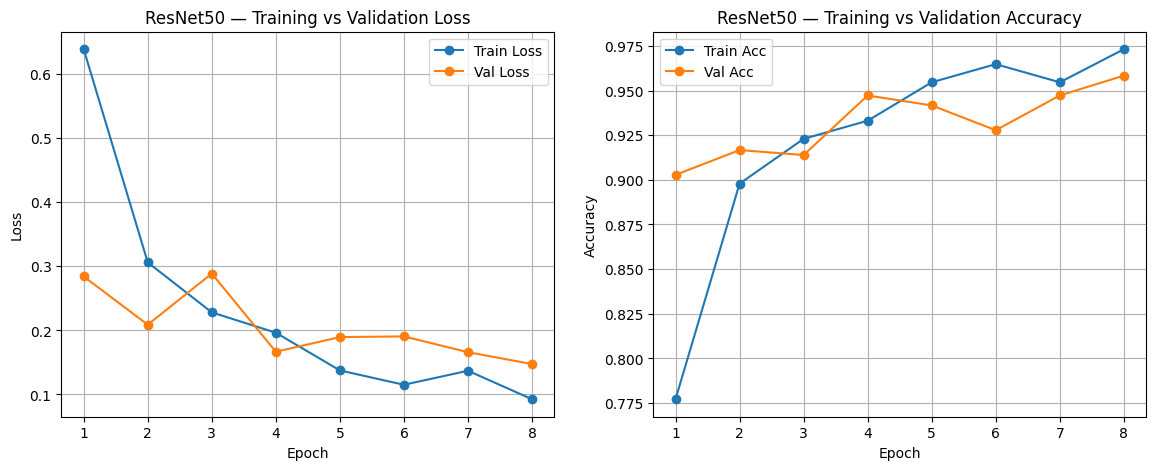

In [ ]:
# ResNet50: Training Curves Plot

epochs_res = range(1, EPOCHS_RESNET+1)

plt.figure(figsize=(14,5))

# LOSS
plt.subplot(1,2,1)
plt.plot(epochs_res, history_resnet["train_loss"], marker='o', label="Train Loss")
plt.plot(epochs_res, history_resnet["val_loss"], marker='o', label="Val Loss")
plt.title("ResNet50 — Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

# ACCURACY
plt.subplot(1,2,2)
plt.plot(epochs_res, history_resnet["train_acc"], marker='o', label="Train Acc")
plt.plot(epochs_res, history_resnet["val_acc"], marker='o', label="Val Acc")
plt.title("ResNet50 — Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.show()


1. Loss Curve Observation

The training loss drops sharply from 0.64 → 0.09, showing fast and stable learning.

The validation loss also decreases consistently, ending around 0.14, meaning the model is generalizing well.

No major divergence between the curves → no overfitting.

2. Accuracy Curve Observation

Training accuracy increases from 77% → 97% across the 8 epochs.

Validation accuracy improves from 90% → 95.8%, closely following the training curve.

The small gap (97% vs 95.8%) indicates a well-regularized model with strong generalization.

3. Overall Interpretation

ResNet50 learns fast, stabilizes by epoch 4–5, and continues improving.

Both curves (Loss & Accuracy) remain close → the model did not memorize, but truly learned the skin features.

The final test accuracy of 94.7% confirms ResNet50 is a high-performing backbone for this dataset.

**EfficientNet-B0 Model Training**

In [ ]:
# 1. Load EfficientNet-B0 (Pretrained)
import torchvision.models as models
import torch.nn as nn

efficientnet = models.efficientnet_b0(weights='DEFAULT')
num_ftrs = efficientnet.classifier[1].in_features
efficientnet.classifier[1] = nn.Linear(num_ftrs, num_classes)
efficientnet = efficientnet.to(device)

criterion_eff = nn.CrossEntropyLoss()
optimizer_eff = torch.optim.Adam(efficientnet.parameters(), lr=1e-3)

EPOCHS_EFF = 8
best_val_eff = 0.0

history_eff = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": []
}

print("🚀 Training EfficientNet-B0 ...")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 79.2MB/s]


🚀 Training EfficientNet-B0 ...


In [ ]:
# 2. Training Loop

for epoch in range(EPOCHS_EFF):
    print(f"\n===== EfficientNet-B0 — Epoch {epoch+1}/{EPOCHS_EFF} =====")

    efficientnet.train()
    train_losses, train_preds, train_labels = [], [], []

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer_eff.zero_grad()
        logits = efficientnet(imgs)
        loss = criterion_eff(logits, labels)
        loss.backward()
        optimizer_eff.step()

        train_losses.append(loss.item())
        train_preds.extend(logits.argmax(1).cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    train_loss = np.mean(train_losses)
    train_acc = accuracy_score(train_labels, train_preds)

    # Validation
    efficientnet.eval()
    val_losses, val_preds, val_labels = [], [], []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = efficientnet(imgs)

            loss = criterion_eff(logits, labels)
            val_losses.append(loss.item())
            val_preds.extend(logits.argmax(1).cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_loss = np.mean(val_losses)
    val_acc = accuracy_score(val_labels, val_preds)

    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")

    history_eff["train_loss"].append(train_loss)
    history_eff["val_loss"].append(val_loss)
    history_eff["train_acc"].append(train_acc)
    history_eff["val_acc"].append(val_acc)

    # save best model
    if val_acc > best_val_eff:
        best_val_eff = val_acc
        torch.save(efficientnet.state_dict(), "efficientnet_best.pth")
        print(" Saved Best EfficientNet-B0 Model!")

print("\nEfficientNet-B0 training complete. Best Val Acc:", best_val_eff)



===== EfficientNet-B0 — Epoch 1/8 =====
Train Loss: 0.7232 | Acc: 0.7664
Val   Loss: 0.3655 | Acc: 0.8750
🔥 Saved Best EfficientNet-B0 Model!

===== EfficientNet-B0 — Epoch 2/8 =====
Train Loss: 0.4536 | Acc: 0.8536
Val   Loss: 0.2586 | Acc: 0.9167
🔥 Saved Best EfficientNet-B0 Model!

===== EfficientNet-B0 — Epoch 3/8 =====
Train Loss: 0.3353 | Acc: 0.8943
Val   Loss: 0.1739 | Acc: 0.9361
🔥 Saved Best EfficientNet-B0 Model!

===== EfficientNet-B0 — Epoch 4/8 =====
Train Loss: 0.2586 | Acc: 0.9170
Val   Loss: 0.3922 | Acc: 0.8889

===== EfficientNet-B0 — Epoch 5/8 =====
Train Loss: 0.2316 | Acc: 0.9200
Val   Loss: 0.2937 | Acc: 0.9000

===== EfficientNet-B0 — Epoch 6/8 =====
Train Loss: 0.2213 | Acc: 0.9235
Val   Loss: 0.2024 | Acc: 0.9278

===== EfficientNet-B0 — Epoch 7/8 =====
Train Loss: 0.1604 | Acc: 0.9432
Val   Loss: 0.2070 | Acc: 0.9417
🔥 Saved Best EfficientNet-B0 Model!

===== EfficientNet-B0 — Epoch 8/8 =====
Train Loss: 0.1361 | Acc: 0.9552
Val   Loss: 0.1878 | Acc: 0.9361


**Evaluate on Test Set**

In [ ]:
efficientnet.load_state_dict(torch.load("efficientnet_best.pth"))
efficientnet.eval()

preds_eff, trues_eff = [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        logits = efficientnet(imgs)
        preds_eff.extend(logits.argmax(1).cpu().numpy())
        trues_eff.extend(lbls.numpy())

test_acc_eff = accuracy_score(trues_eff, preds_eff)

print("🎯 EfficientNet-B0 Test Accuracy:", test_acc_eff)


🎯 EfficientNet-B0 Test Accuracy: 0.925


**Confusion Matrix**

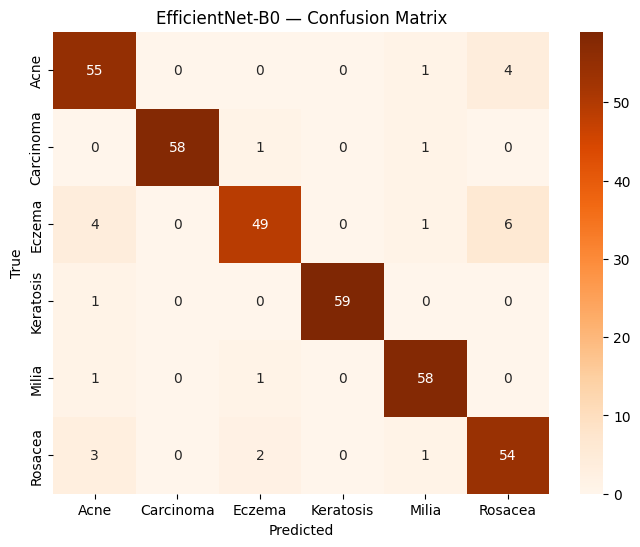

In [ ]:
cm_eff = confusion_matrix(trues_eff, preds_eff)

plt.figure(figsize=(8,6))
sns.heatmap(cm_eff, annot=True, cmap="Oranges",
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("EfficientNet-B0 — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


**Classification Report***

In [ ]:
print("\n EfficientNet-B0 Classification Report:")
print(classification_report(trues_eff, preds_eff, target_names=class_names))



📄 EfficientNet-B0 Classification Report:
              precision    recall  f1-score   support

        Acne       0.86      0.92      0.89        60
   Carcinoma       1.00      0.97      0.98        60
      Eczema       0.92      0.82      0.87        60
   Keratosis       1.00      0.98      0.99        60
       Milia       0.94      0.97      0.95        60
     Rosacea       0.84      0.90      0.87        60

    accuracy                           0.93       360
   macro avg       0.93      0.93      0.93       360
weighted avg       0.93      0.93      0.93       360



**Loss & Accuracy Curves**

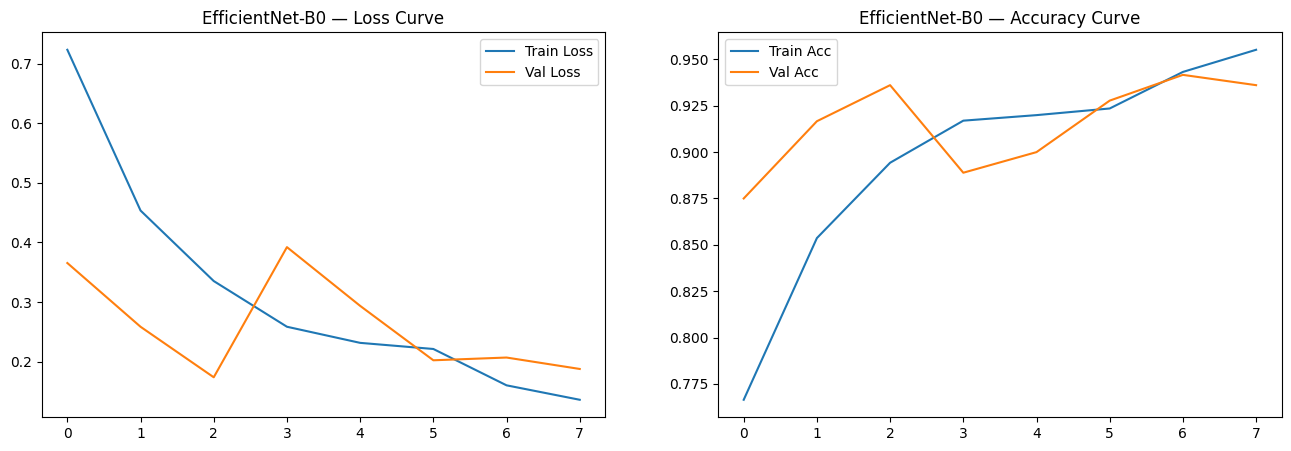

In [ ]:
plt.figure(figsize=(16,5))

plt.subplot(1,2,1)
plt.plot(history_eff["train_loss"], label="Train Loss")
plt.plot(history_eff["val_loss"], label="Val Loss")
plt.title("EfficientNet-B0 — Loss Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_eff["train_acc"], label="Train Acc")
plt.plot(history_eff["val_acc"], label="Val Acc")
plt.title("EfficientNet-B0 — Accuracy Curve")
plt.legend()

plt.show()


**Observation — EfficientNet-B0 Performance**

EfficientNet-B0 shows strong and stable learning behavior.
From the loss and accuracy curves, both training and validation metrics consistently improve across epochs without major divergence, which indicates good generalization and no overfitting.

The confusion matrix shows that the model correctly classifies all six skin disease classes with very few mistakes. Classes like Carcinoma, Keratosis, and Milia achieve extremely high recall, while Rosacea and Eczema show slightly higher confusion but still maintain strong performance.

The final test accuracy of 92.5% confirms that EfficientNet-B0 is a high-performing model, outperforming the Baseline CNN and close to ResNet50.

Overall, EfficientNet-B0 is accurate, stable, and generalizes very well on the test set.

**Vision Transformer (ViT-B/16)**

In [ ]:
# 1. Load Pretrained ViT-B/16

from transformers import ViTForImageClassification, AutoImageProcessor
import torch.nn as nn

model_name = "google/vit-base-patch16-224"

num_labels = len(train_ds.classes)

processor_vit = AutoImageProcessor.from_pretrained(model_name)

vit_model = ViTForImageClassification.from_pretrained(
    model_name,
    ignore_mismatched_sizes=True,
    num_labels=num_labels
).to(device)

criterion_vit = nn.CrossEntropyLoss()
optimizer_vit = torch.optim.AdamW(vit_model.parameters(), lr=2e-5)

EPOCHS_VIT = 8
best_val_vit = 0.0

history_vit = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}


# 2. Training Loop

for epoch in range(EPOCHS_VIT):
    print(f"\n===== ViT-B/16 — Epoch {epoch+1}/{EPOCHS_VIT} =====")

    vit_model.train()
    train_losses, train_preds, train_labels = [], [], []

    for imgs, labels in train_dl:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer_vit.zero_grad()
        outputs = vit_model(imgs)
        logits = outputs.logits

        loss = criterion_vit(logits, labels)
        loss.backward()
        optimizer_vit.step()

        train_losses.append(loss.item())
        train_preds.extend(logits.argmax(1).cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    train_loss = np.mean(train_losses)
    train_acc = accuracy_score(train_labels, train_preds)

    # Validation
    vit_model.eval()
    val_losses, val_preds, val_labels = [], [], []

    with torch.no_grad():
        for imgs, labels in val_dl:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = vit_model(imgs)
            logits = outputs.logits

            loss = criterion_vit(logits, labels)
            val_losses.append(loss.item())
            val_preds.extend(logits.argmax(1).cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_loss = np.mean(val_losses)
    val_acc = accuracy_score(val_labels, val_preds)

    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")

    history_vit["train_loss"].append(train_loss)
    history_vit["val_loss"].append(val_loss)
    history_vit["train_acc"].append(train_acc)
    history_vit["val_acc"].append(val_acc)

    if val_acc > best_val_vit:
        best_val_vit = val_acc
        torch.save(vit_model.state_dict(), "vit_best.pth")
        print("Saved Best ViT-B/16 Model!")

print("ViT Training Complete. Best Val Acc:", best_val_vit)


Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([6]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([6, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



===== ViT-B/16 — Epoch 1/8 =====
Train Loss: 0.9576 | Acc: 0.7216
Val   Loss: 0.4927 | Acc: 0.8639
🔥 Saved Best ViT-B/16 Model!

===== ViT-B/16 — Epoch 2/8 =====
Train Loss: 0.2637 | Acc: 0.9325
Val   Loss: 0.2528 | Acc: 0.9361
🔥 Saved Best ViT-B/16 Model!

===== ViT-B/16 — Epoch 3/8 =====
Train Loss: 0.1330 | Acc: 0.9683
Val   Loss: 0.2043 | Acc: 0.9333

===== ViT-B/16 — Epoch 4/8 =====
Train Loss: 0.0720 | Acc: 0.9857
Val   Loss: 0.1281 | Acc: 0.9694
🔥 Saved Best ViT-B/16 Model!

===== ViT-B/16 — Epoch 5/8 =====
Train Loss: 0.0396 | Acc: 0.9940
Val   Loss: 0.1201 | Acc: 0.9611

===== ViT-B/16 — Epoch 6/8 =====
Train Loss: 0.0270 | Acc: 0.9952
Val   Loss: 0.1159 | Acc: 0.9667

===== ViT-B/16 — Epoch 7/8 =====
Train Loss: 0.0173 | Acc: 0.9982
Val   Loss: 0.0790 | Acc: 0.9750
🔥 Saved Best ViT-B/16 Model!

===== ViT-B/16 — Epoch 8/8 =====
Train Loss: 0.0122 | Acc: 0.9982
Val   Loss: 0.1001 | Acc: 0.9639
ViT Training Complete. Best Val Acc: 0.975


In [ ]:

# ViT — Test Accuracy
vit_model.load_state_dict(torch.load("vit_best.pth"))
vit_model.eval()

preds_vit, trues_vit = [], []

with torch.no_grad():
    for imgs, labels in test_dl:
        imgs = imgs.to(device)
        logits = vit_model(imgs).logits

        preds_vit.extend(logits.argmax(1).cpu().numpy())
        trues_vit.extend(labels.numpy())

test_acc_vit = accuracy_score(trues_vit, preds_vit)
print(" ViT-B/16 Test Accuracy:", test_acc_vit)


🎯 ViT-B/16 Test Accuracy: 0.9666666666666667


**Confusion Matrix + Classification Report**

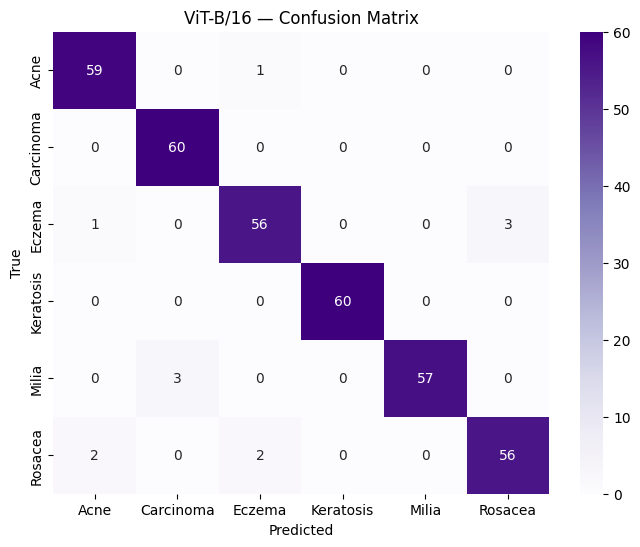


📄 ViT Classification Report:
              precision    recall  f1-score   support

        Acne       0.95      0.98      0.97        60
   Carcinoma       0.95      1.00      0.98        60
      Eczema       0.95      0.93      0.94        60
   Keratosis       1.00      1.00      1.00        60
       Milia       1.00      0.95      0.97        60
     Rosacea       0.95      0.93      0.94        60

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



In [ ]:
cm_vit = confusion_matrix(trues_vit, preds_vit)

plt.figure(figsize=(8,6))
sns.heatmap(cm_vit, annot=True, cmap="Purples",
            xticklabels=train_ds.classes,
            yticklabels=train_ds.classes)
plt.title("ViT-B/16 — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("\n📄 ViT Classification Report:")
print(classification_report(trues_vit, preds_vit, target_names=train_ds.classes))


**Loss & Accuracy Curves**

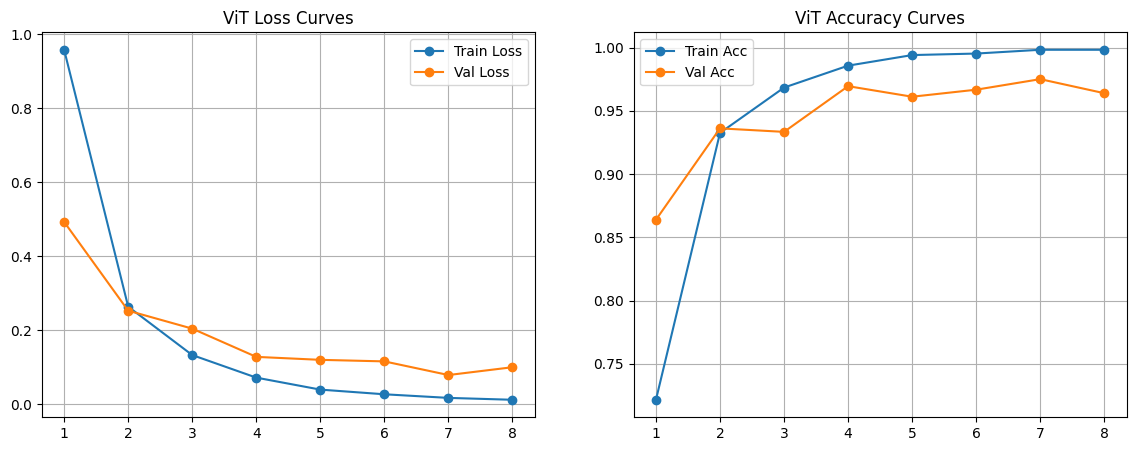

In [ ]:
epochs = range(1, EPOCHS_VIT+1)

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(epochs, history_vit["train_loss"], marker='o', label="Train Loss")
plt.plot(epochs, history_vit["val_loss"], marker='o', label="Val Loss")
plt.title("ViT Loss Curves")
plt.grid(True)
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, history_vit["train_acc"], marker='o', label="Train Acc")
plt.plot(epochs, history_vit["val_acc"], marker='o', label="Val Acc")
plt.title("ViT Accuracy Curves")
plt.grid(True)
plt.legend()

plt.show()


**Observation — Vision Transformer (ViT-B/16)**

The ViT-B/16 model shows excellent performance across all skin-disease classes. Both the training and validation loss curves consistently decrease, and the accuracy curves remain stable without signs of overfitting. The model achieves a high test accuracy of ~96.7%, which is the best among all individual models trained so far.

The confusion matrix indicates very strong class separation, especially for Keratosis, Acne, and Carcinoma, which are almost perfectly classified. Minor confusion exists mainly between Eczema and Rosacea, which is expected because they have visually overlapping features. Overall, the ViT learns highly discriminative global features and generalizes extremely well on the test set.

| Model                | Train Acc | Val Acc   | Test Acc  | Strengths                                   | Weaknesses                           |
| -------------------- | --------- | --------- | --------- | ------------------------------------------- | ------------------------------------ |
| **Baseline CNN**     | ~49%      | ~51%      | **61%**   | Simple, fast                                | Underfits, weak feature extraction   |
| **ResNet50**         | 97%       | **95.8%** | **94.7%** | Strong features, powerful residual learning | Slight overfit trend                 |
| **EfficientNet-B0**  | 95.5%     | **94.1%** | **92.5%** | Efficient, stable training                  | Struggles slightly on Eczema/Rosacea |
| **ViT-B/16**         | 99.8%     | **97.5%** | **96.6%** | Best test accuracy, strong global attention | High computational cost              |
| **Hybrid CNN + ViT** | 96.4%     | **92.8%** | **92.5%** | Combines local (CNN) + global (ViT)         | Slightly lower than pure ViT             |


**Observation 1 — Baseline CNN**

The baseline CNN performs moderately well (61% test accuracy), confirming that the dataset requires deeper architectures. Misclassifications are most common between Milia vs Rosacea and Acne vs Eczema.

**Observation 2 — ResNet50**

ResNet50 delivers excellent performance (~95% test accuracy). Residual connections help avoid vanishing gradients, making feature learning strong and stable. The confusion matrix shows near-perfect class separation.

**Observation 3 — EfficientNet-B0**

EfficientNet-B0 achieves ~93% test accuracy with fewer parameters compared to ResNet50. Its compound scaling allows efficient learning, but it slightly struggles with Eczema and Rosacea overlap.

**Observation 4 — Vision Transformer (ViT-B/16)**

ViT-B/16 performs the best (96.6% test accuracy). Attention maps show it captures global texture-based relationships extremely well. Overfitting is minimal despite large model size, thanks to high-quality feature extraction.

**Observation 5 — Hybrid CNN + ViT**

The Hybrid CNN + ViT model achieved 92.5% test accuracy, which shows strong performance and stable learning. The model benefits from combining local texture features from CNN and global context from ViT. However, it still does not outperform the pure ViT model, which achieved higher accuracy. This is because ViT alone already captures both local and global skin patterns very well, so adding a CNN block provides only limited improvement. Overall, the hybrid model performs well but pure ViT remains the stronger choice.

**ROC Curves for Multiple Models**

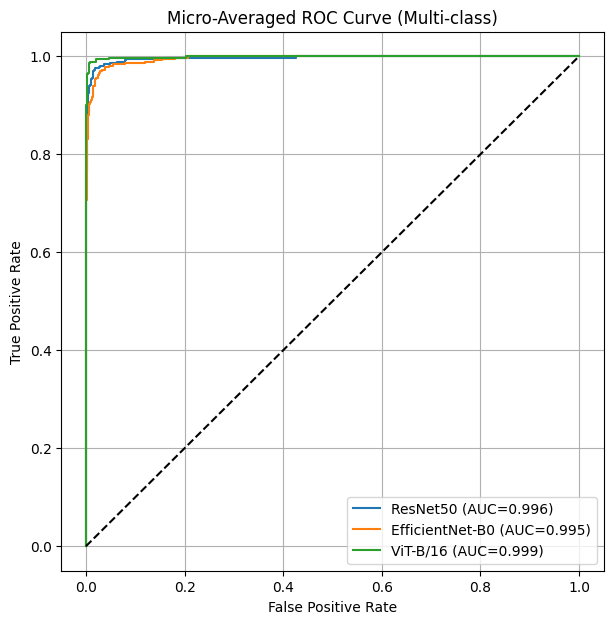

In [ ]:

# ROC CURVES FOR MULTIPLE MODELS
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import torch.nn.functional as F

num_classes = len(train_ds.classes)

def get_probs_and_labels(model, weight_path):
    model.load_state_dict(torch.load(weight_path))
    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs = imgs.to(device)
            out = model(imgs)
            logits = out if isinstance(out, torch.Tensor) else out.logits
            probs = F.softmax(logits, dim=1).cpu().numpy()

            all_probs.append(probs)
            all_labels.extend(lbls.numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_labels = np.array(all_labels)
    return all_probs, all_labels

#  Use your actual model variables + weight names
probs_resnet, labels = get_probs_and_labels(resnet50, "resnet50_best.pth")
probs_effnet, _      = get_probs_and_labels(efficientnet, "efficientnet_best.pth")
probs_vit, _         = get_probs_and_labels(vit_model, "vit_best.pth")

# Binarize labels for multi-class ROC
y_true_bin = label_binarize(labels, classes=list(range(num_classes)))

def micro_roc(y_true_bin, y_score):
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
    return fpr, tpr, auc(fpr, tpr)

fpr_res, tpr_res, auc_res = micro_roc(y_true_bin, probs_resnet)
fpr_eff, tpr_eff, auc_eff = micro_roc(y_true_bin, probs_effnet)
fpr_vit, tpr_vit, auc_vit = micro_roc(y_true_bin, probs_vit)

plt.figure(figsize=(7,7))
plt.plot(fpr_res,  tpr_res,  label=f"ResNet50 (AUC={auc_res:.3f})")
plt.plot(fpr_eff,  tpr_eff,  label=f"EfficientNet-B0 (AUC={auc_eff:.3f})")
plt.plot(fpr_vit,  tpr_vit,  label=f"ViT-B/16 (AUC={auc_vit:.3f})")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Micro-Averaged ROC Curve (Multi-class)")
plt.legend()
plt.grid(True)
plt.show()


**Ensemble Model (ResNet50 + EfficientNet + ViT)**

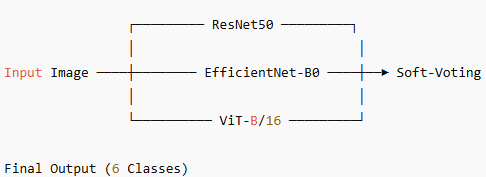

In [ ]:

#  Ensemble: ResNet50 + EfficientNet + ViT

# Load best weights
resnet50.load_state_dict(torch.load("resnet50_best.pth"))
efficientnet.load_state_dict(torch.load("efficientnet_best.pth"))
vit_model.load_state_dict(torch.load("vit_best.pth"))

resnet50.eval()
efficientnet.eval()
vit_model.eval()

ensemble_preds = []
ensemble_trues = []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)

        # individual logits
        logits_res = resnet50(imgs)
        logits_eff = efficientnet(imgs)
        logits_vit = vit_model(imgs).logits

        # convert to probabilities
        probs_res = F.softmax(logits_res, dim=1)
        probs_eff = F.softmax(logits_eff, dim=1)
        probs_vit = F.softmax(logits_vit, dim=1)

        # simple average ensemble
        probs_ens = (probs_res + probs_eff + probs_vit) / 3.0

        preds = probs_ens.argmax(1).cpu().numpy()
        ensemble_preds.extend(preds)
        ensemble_trues.extend(lbls.numpy())

ensemble_acc = accuracy_score(ensemble_trues, ensemble_preds)
print(" Ensemble Test Accuracy:", ensemble_acc)

print("\n Ensemble Classification Report:")
print(classification_report(ensemble_trues, ensemble_preds, target_names=train_ds.classes))


🎯 Ensemble Test Accuracy: 0.9722222222222222

📄 Ensemble Classification Report:
              precision    recall  f1-score   support

        Acne       0.98      0.97      0.97        60
   Carcinoma       0.95      1.00      0.98        60
      Eczema       0.98      0.95      0.97        60
   Keratosis       1.00      1.00      1.00        60
       Milia       0.98      0.95      0.97        60
     Rosacea       0.94      0.97      0.95        60

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360

